# 🏒 VIZER NHL — 02b · Données Play-by-Play (P1 dédiées)

**À lancer une seule fois** (ou quand tu veux mettre à jour les données 2025).

Ce notebook télécharge les fichiers `shots` de Moneypuck et les agrège en `period_stats.csv` (~1500 lignes par saison au lieu de 250 000 shots).

**Fichiers source (~2.5GB compressés total) :**
- `shots_2007-2024.zip` (~2.3GB)
- `shots_2025.zip` (~150MB)

**Output :** `period_stats.csv` (~3MB) avec colonnes `gameId, team, period, goals, xGoals, shots`.

In [6]:
import pandas as pd
import numpy as np
import requests
import zipfile
import io
import os
import gc
import time
from datetime import datetime
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# ── Configuration ─────────────────────────────────────────────────────────────
DRIVE_PATH = '/home/noxtheteenager/Documents/Projets/vizer_info_model/hockey/nhl'

SHOTS_FILES = {
    'historique': {
        'url':     'https://peter-tanner.com/moneypuck/downloads/shots_2007-2024.zip',
        'zip':     os.path.join(DRIVE_PATH, 'shots_2007-2024.zip'),
        'csv':     os.path.join(DRIVE_PATH, 'shots_2007-2024.csv'),
        'size_mb': 2300,
    },
    'saison_courante': {
        'url':     'https://peter-tanner.com/moneypuck/downloads/shots_2025.zip',
        'zip':     os.path.join(DRIVE_PATH, 'shots_2025.zip'),
        'csv':     os.path.join(DRIVE_PATH, 'shots_2025.csv'),
        'size_mb': 150,
    },
}

OUTPUT_PERIOD_STATS = os.path.join(DRIVE_PATH, 'period_stats.csv')
CHUNK_SIZE = 200_000  # Lignes traitées en une fois (gestion mémoire)

# Colonnes nécessaires (~95% économie d'espace mémoire vs toutes les colonnes)
# Colonnes nécessaires — 'season' est CRITIQUE pour construire le gameId Moneypuck complet
# (le fichier shots stocke game_id sur 5 chiffres par saison, mais le team data utilise 10 chiffres)
# Colonnes nécessaires — version étendue V5.5 :
# - 'season', 'game_id'                     : reconstruction gameId complet (10 chiffres)
# - 'teamCode'                              : équipe qui tire (For)
# - 'period', 'goal', 'xGoal', 'shotWasOnGoal' : stats par période
# - 'homeTeamGoals', 'awayTeamGoals'        : score AVANT le tir → pondération CSA
# - 'isHomeTeam'                            : sens du tir (For/Against pour normaliser)
SHOT_COLS = ['game_id', 'season', 'teamCode', 'period', 'goal', 'xGoal',
             'shotWasOnGoal', 'homeTeamGoals', 'awayTeamGoals', 'isHomeTeam']

print(f'✅ Config chargée — {datetime.now().strftime("%d/%m/%Y %H:%M")}')
print(f'   Chunks de {CHUNK_SIZE:,} lignes pour gestion mémoire')

✅ Config chargée — 14/05/2026 17:09
   Chunks de 200,000 lignes pour gestion mémoire


## ⬇️ Téléchargement des shots

**Avertissement :** le fichier historique fait ~2.3GB compressé. Téléchargement long (5-15 min selon connexion). Si tu as déjà les CSV décompressés, le notebook les utilisera directement et sautera le download.

In [7]:
from vizer_utils import normalize_teams

def download_shots_zip(info, label):
    """Télécharge et décompresse un fichier shots zip s'il n'est pas déjà présent."""
    # Cas 1 : CSV déjà décompressé → on l'utilise
    if os.path.exists(info['csv']):
        size = os.path.getsize(info['csv']) / 1e6
        print(f'   ✓ {label.upper():<18} CSV présent ({size:.0f} MB) → réutilisation')
        return info['csv']
    
    # Cas 2 : ZIP présent → décompresser
    if os.path.exists(info['zip']):
        print(f'   📦 {label.upper():<18} ZIP présent → décompression...')
        with zipfile.ZipFile(info['zip']) as z:
            csv_name = [f for f in z.namelist() if f.endswith('.csv')][0]
            z.extract(csv_name, DRIVE_PATH)
            extracted = os.path.join(DRIVE_PATH, csv_name)
            if extracted != info['csv']:
                os.rename(extracted, info['csv'])
        print(f'   ✓ Décompressé → {info["csv"]}')
        return info['csv']
    
    # Cas 3 : Téléchargement nécessaire
    print(f'   ⬇️ {label.upper():<18} Téléchargement ({info["size_mb"]} MB)...')
    t0 = time.time()
    r = requests.get(info['url'], stream=True, timeout=600)
    r.raise_for_status()
    
    total_size = int(r.headers.get('content-length', 0))
    downloaded = 0
    with open(info['zip'], 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192 * 128):
            f.write(chunk)
            downloaded += len(chunk)
            if total_size:
                pct = 100 * downloaded / total_size
                if downloaded % (50 * 1024 * 1024) < 8192 * 128:  # log tous les 50MB
                    print(f'      {pct:.0f}% ({downloaded/1e6:.0f}/{total_size/1e6:.0f} MB)')
    
    print(f'   ✓ Téléchargé en {time.time()-t0:.0f}s — décompression...')
    with zipfile.ZipFile(info['zip']) as z:
        csv_name = [f for f in z.namelist() if f.endswith('.csv')][0]
        z.extract(csv_name, DRIVE_PATH)
        extracted = os.path.join(DRIVE_PATH, csv_name)
        if extracted != info['csv']:
            os.rename(extracted, info['csv'])
    print(f'   ✓ Prêt → {info["csv"]}')
    return info['csv']


for label, info in SHOTS_FILES.items():
    download_shots_zip(info, label)
print('\n✅ Tous les fichiers shots prêts')

   ✓ HISTORIQUE         CSV présent (1168 MB) → réutilisation
   ✓ SAISON_COURANTE    CSV présent (66 MB) → réutilisation

✅ Tous les fichiers shots prêts


## ⚙️ Agrégation par (gameId, team, period)

Chaque shot devient une ligne dans le CSV brut. On agrège pour avoir **une ligne par équipe par période** :
- `goals` (somme des shots avec goal=1)
- `xGoals` (somme des xGoal)
- `shots_on_goal` (somme avec shotWasOnGoal=1)

In [8]:
import numpy as np
def aggregate_shots_to_periods(csv_path, label):
    """Agrège shots → stats par (game, team, period) en chunks pour économiser la RAM."""
    print(f'\n📊 Agrégation {label.upper()}...')
    t0 = time.time()
    
    # Détecter le séparateur (Moneypuck utilise parfois ',' ou ';')
    with open(csv_path, 'r') as f:
        header = f.readline()
    sep = ',' if header.count(',') > header.count(';') else ';'
    
    # Identifier les colonnes réelles (Moneypuck a varié les noms au fil des saisons)
    actual_cols = pd.read_csv(csv_path, sep=sep, nrows=0).columns.tolist()
    col_map = {}
    for needed in SHOT_COLS:
        # Lookup avec variations courantes
        for actual in actual_cols:
            if actual.lower() == needed.lower() or actual.lower().replace('_', '') == needed.lower().replace('_', ''):
                col_map[needed] = actual
                break
    
    if 'game_id' not in col_map or 'period' not in col_map or 'season' not in col_map:
        missing = [c for c in ['game_id', 'season', 'period'] if c not in col_map]
        print(f'   ⚠️  Colonnes manquantes ({missing}) dans {csv_path}')
        print(f'   Colonnes disponibles : {actual_cols[:15]}...')
        return pd.DataFrame()
    
    cols_to_read = list(col_map.values())
    print(f'   Colonnes utilisées : {cols_to_read}')
    
    # Lecture par chunks + agrégation incrémentale
    aggregated_chunks = []
    n_chunks, n_rows = 0, 0
    for chunk in pd.read_csv(csv_path, sep=sep, usecols=cols_to_read, chunksize=CHUNK_SIZE):
        n_chunks += 1
        n_rows += len(chunk)
        
        # Renommer les colonnes en noms standards
        chunk = chunk.rename(columns={v: k for k, v in col_map.items()})
        
        # Garder uniquement périodes 1-3 (P4/P5 = OT/SO, hors scope P1)
        chunk = chunk[chunk['period'].between(1, 3)]
        if chunk.empty:
            continue
        
        # Normaliser les codes équipe (TEAM_REMAP)
        chunk = chunk.rename(columns={'teamCode': 'team'})
        chunk = normalize_teams(chunk)
        
        # CRITIQUE : construire le gameId complet (10 chiffres) compatible avec team data
        # Moneypuck format : season * 1_000_000 + game_id
        chunk['gameId'] = (chunk['season'].astype('int64') * 1_000_000 +
                           chunk['game_id'].astype('int64'))
        
        # === Score-Adjusted Corsi (CSA) ===
        # Pondération standard hockey analytics selon différentiel de score :
        # - Match serré (|diff| <= 1) : poids 1.0
        # - Avantage 2 buts : poids 0.50 (l'équipe qui mène défend, fausse les stats)
        # - Avantage 3+ buts : poids 0.25 ("garbage time")
        # On utilise homeTeamGoals/awayTeamGoals AVANT chaque tir.
        if 'homeTeamGoals' in chunk.columns and 'isHomeTeam' in chunk.columns:
            # Calcul du diff de score du point de vue de l'équipe qui tire
            chunk['score_diff_for_shooter'] = np.where(
                chunk['isHomeTeam'] == 1,
                chunk['homeTeamGoals'] - chunk['awayTeamGoals'],
                chunk['awayTeamGoals'] - chunk['homeTeamGoals']
            )
            abs_diff = chunk['score_diff_for_shooter'].abs()
            chunk['csa_weight'] = np.select(
                [abs_diff <= 1, abs_diff == 2, abs_diff >= 3],
                [1.0, 0.50, 0.25],
                default=1.0
            )
            # Corsi pondéré : chaque tir compte selon le poids du contexte
            chunk['csa_shot'] = chunk['csa_weight']
        else:
            chunk['csa_shot'] = 1.0  # fallback : pas de pondération
        
        # Agréger par (gameId complet, team, period)
        agg = chunk.groupby(['gameId', 'team', 'period']).agg(
            goals=('goal', 'sum'),
            xGoals=('xGoal', 'sum'),
            shots_on_goal=('shotWasOnGoal', 'sum') if 'shotWasOnGoal' in chunk.columns else ('goal', 'count'),
            csa_shots_for=('csa_shot', 'sum'),  # NOUVEAU : Corsi pondéré For
        ).reset_index()
        aggregated_chunks.append(agg)
        
        if n_chunks % 5 == 0:
            print(f'   Chunk {n_chunks:>3} traité ({n_rows/1e6:.1f}M lignes lues)')
    
    # Re-aggréger les résultats par chunk
    full = pd.concat(aggregated_chunks, ignore_index=True)
    final = full.groupby(['gameId', 'team', 'period']).agg(
        goals=('goals', 'sum'),
        xGoals=('xGoals', 'sum'),
        shots_on_goal=('shots_on_goal', 'sum'),
        csa_shots_for=('csa_shots_for', 'sum'),
    ).reset_index()
    
    print(f'   ✓ {n_rows:,} shots → {len(final):,} lignes (gameId×team×period) en {time.time()-t0:.0f}s')
    print(f'      Exemples gameId : {final["gameId"].iloc[:3].tolist()} (format 10 chiffres = season+game)')
    del aggregated_chunks, full
    gc.collect()
    return final


# Traiter historique + saison courante
df_hist  = aggregate_shots_to_periods(SHOTS_FILES['historique']['csv'],       'historique')
df_curr  = aggregate_shots_to_periods(SHOTS_FILES['saison_courante']['csv'], 'saison_courante')

period_stats = pd.concat([df_hist, df_curr], ignore_index=True)
period_stats = period_stats.drop_duplicates(subset=['gameId', 'team', 'period'], keep='last')

# Calcul CSA% par (gameId, team) — somme P1+P2+P3, ratio For/(For+Against)
# CSA_For d'une équipe = sa propre somme de tirs pondérés
# CSA_Against d'une équipe = tirs pondérés de l'adversaire dans le même match
csa_per_game = period_stats.groupby(['gameId', 'team'])['csa_shots_for'].sum().reset_index()
csa_per_game.columns = ['gameId', 'team', 'csa_for']

# Pour chaque match, retrouver le total de tirs des DEUX équipes → calculer Against
game_totals = csa_per_game.groupby('gameId')['csa_for'].sum().reset_index()
game_totals.columns = ['gameId', 'csa_total']
csa_per_game = csa_per_game.merge(game_totals, on='gameId')
csa_per_game['csa_against'] = csa_per_game['csa_total'] - csa_per_game['csa_for']
csa_per_game['csa_pct'] = csa_per_game['csa_for'] / (csa_per_game['csa_total'] + 0.001)
csa_per_game = csa_per_game[['gameId', 'team', 'csa_for', 'csa_against', 'csa_pct']]

# Sauvegarde séparée
csa_per_game.to_csv(os.path.join(DRIVE_PATH, 'csa_stats.csv'), index=False)
print(f'✅ csa_stats.csv sauvegardé : {len(csa_per_game):,} lignes (gameId × team)')
print(f'   CSA% moyen : {csa_per_game["csa_pct"].mean():.1%} (référence : ~50%)')
# gameId déjà au bon format depuis aggregate_shots_to_periods

print(f'\n✅ period_stats prêt : {len(period_stats):,} lignes ({period_stats["gameId"].nunique():,} matchs uniques)')


📊 Agrégation HISTORIQUE...
   Colonnes utilisées : ['game_id', 'season', 'teamCode', 'period', 'goal', 'xGoal', 'shotWasOnGoal', 'homeTeamGoals', 'awayTeamGoals', 'isHomeTeam']
   Chunk   5 traité (1.0M lignes lues)
   Chunk  10 traité (2.0M lignes lues)
   ✓ 1,960,088 shots → 138,814 lignes (gameId×team×period) en 7s
      Exemples gameId : [2007020001, 2007020001, 2007020001] (format 10 chiffres = season+game)

📊 Agrégation SAISON_COURANTE...
   Colonnes utilisées : ['game_id', 'season', 'teamCode', 'period', 'goal', 'xGoal', 'shotWasOnGoal', 'homeTeamGoals', 'awayTeamGoals', 'isHomeTeam']
   ✓ 117,247 shots → 8,226 lignes (gameId×team×period) en 0s
      Exemples gameId : [2025020001, 2025020001, 2025020001] (format 10 chiffres = season+game)
✅ csa_stats.csv sauvegardé : 49,026 lignes (gameId × team)
   CSA% moyen : 50.0% (référence : ~50%)

✅ period_stats prêt : 147,040 lignes (24,513 matchs uniques)


## 🔎 Validation et visualisation

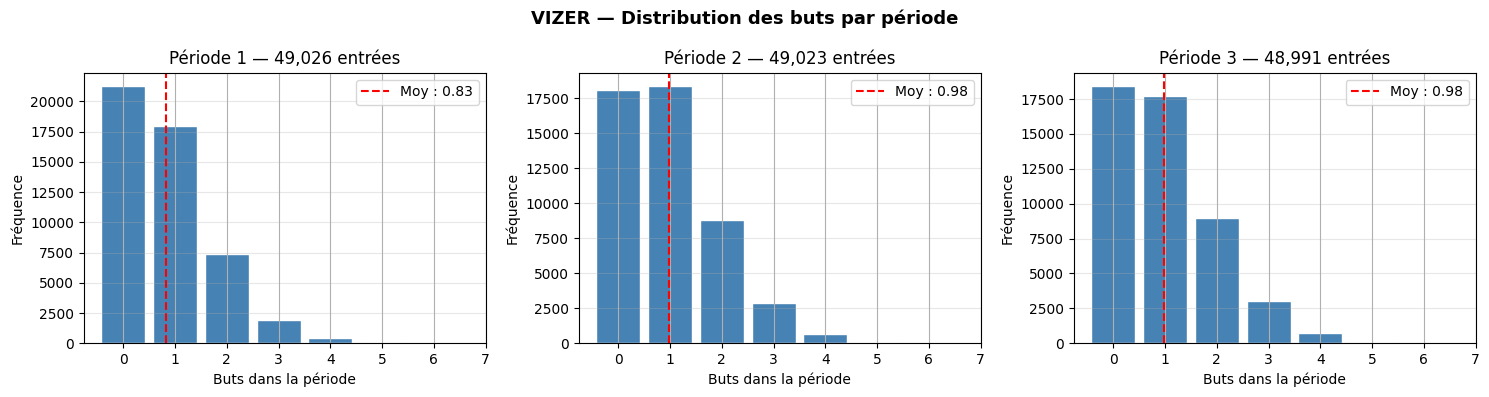


📊 Validation du ratio P1 :
   Période 1 : 40,506 buts (29.6% du total)
   Période 2 : 47,980 buts (35.1% du total)
   Période 3 : 48,183 buts (35.3% du total)

   Confirmation : P1_GOAL_RATIO = 0.30 (cohérent avec la réalité)
   → P1 réelle = 29.6%  ✅ OK


In [9]:
# Validation : distribution buts par période
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('VIZER — Distribution des buts par période', fontsize=13, fontweight='bold')

for idx, period in enumerate([1, 2, 3]):
    ax = axes[idx]
    sub = period_stats[period_stats['period'] == period]['goals']
    sub.hist(bins=range(0, 8), ax=ax, color='steelblue', edgecolor='white', align='left', rwidth=0.85)
    mean_g = sub.mean()
    ax.axvline(mean_g, color='red', linestyle='--', linewidth=1.5, label=f'Moy : {mean_g:.2f}')
    ax.set_title(f'Période {period} — {len(sub):,} entrées')
    ax.set_xlabel('Buts dans la période')
    ax.set_ylabel('Fréquence')
    ax.set_xticks(range(0, 8))
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('period_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

# Ratio P1 / Total (vérification de l'approximation 0.33)
goals_by_period = period_stats.groupby('period')['goals'].sum()
total_goals = goals_by_period.sum()
print(f'\n📊 Validation du ratio P1 :')
for p, n in goals_by_period.items():
    ratio = n / total_goals
    print(f'   Période {p} : {n:,} buts ({ratio:.1%} du total)')
print(f'\n   Confirmation : P1_GOAL_RATIO = 0.30 (cohérent avec la réalité)')
ratio_p1 = goals_by_period[1]/total_goals
print(f'   → P1 réelle = {ratio_p1:.1%}  ', end='')
print('✅ OK' if 0.27 <= ratio_p1 <= 0.32 else '⚠️ écart anormal')

## 💾 Sauvegarde period_stats.csv

In [10]:
period_stats.to_csv(OUTPUT_PERIOD_STATS, index=False)
size_mb = os.path.getsize(OUTPUT_PERIOD_STATS) / 1e6
print(f'✅ period_stats.csv sauvegardé ({size_mb:.1f} MB)')
print(f'   Lignes : {len(period_stats):,}')
print(f'   Matchs uniques : {period_stats["gameId"].nunique():,}')
print(f'   Équipes : {period_stats["team"].nunique()}')
print(f'\n➡️  Lance maintenant 02_Agregation.ipynb (il détectera period_stats.csv automatiquement)')
print(f'    puis 03_Entrainement.ipynb pour entraîner les Poisson P1 dédiés')

# Aperçu
display(period_stats.head(10))

✅ period_stats.csv sauvegardé (6.7 MB)
   Lignes : 147,040
   Matchs uniques : 24,513
   Équipes : 32

➡️  Lance maintenant 02_Agregation.ipynb (il détectera period_stats.csv automatiquement)
    puis 03_Entrainement.ipynb pour entraîner les Poisson P1 dédiés


,gameId,team,period,goals,xGoals,shots_on_goal,csa_shots_for
0,2007020001,ANA,1,0,1.279036,14.0,20.0
1,2007020001,ANA,2,0,1.252443,20.0,17.0
2,2007020001,ANA,3,2,3.242867,20.0,9.0
3,2007020001,LAK,1,2,1.535276,14.0,18.0
4,2007020001,LAK,2,2,1.160100,14.0,14.0
5,2007020001,LAK,3,4,2.724294,14.0,6.5
6,2007020002,ANA,1,4,2.401693,18.0,21.0
7,2007020002,ANA,2,4,1.228931,20.0,10.0
8,2007020002,ANA,3,0,1.340351,12.0,4.5
9,2007020002,LAK,1,0,0.372658,12.0,10.0
